## Load replay buffer

In [ ]:
import torch
import os
from src.utils import load_replay_buffer
from src.learning.bb_symmetry.kernel_approx import KernelFrameEstimator

LEARN_KERNEL_BASES: bool=True
folder_name: str="data/local/experiment/circle_rotation"
TASK_NAMES=["sac_circle_rotation_task_0", "sac_circle_rotation_task_1", "sac_circle_rotation_task_2", "sac_circle_rotation_task_3"]
N_SAMPLES:int=50_000
KERNEL_DIM=1
EPSILON_BALL = 0.005
EPSILON_LEVEL_SET = 0.0025

def load_data(task_name, kernel_in, kernel_out, n_samples, folder_name:str):
    """
    Load data from the replay buffer.
    """
    replay_buffer_name:str=os.path.join(folder_name,task_name+"_replay_buffer.pkl")
    replay_buffer = load_replay_buffer(replay_buffer_name, N_steps=n_samples)
    assert kernel_in in replay_buffer.keys(), f"Kernel input {kernel_in} not found in replay buffer keys: {replay_buffer.keys()}"
    assert kernel_out in replay_buffer.keys(), f"Kernel output {kernel_out} not found in replay buffer keys: {replay_buffer.keys()}"
    
    ps = replay_buffer[kernel_in]
    ns = replay_buffer[kernel_out]
    
    return ps, ns


def learn_kernel_bases(task_name: str, kernel_in, kernel_out, n_samples: int, kernel_dim: int, epsilon_ball: float, epsilon_level_set: float):
    """
    Learn kernel bases from the replay buffer.
    """
    ps, ns=load_data(task_name, kernel_in, kernel_out, n_samples, folder_name)

    frame_estimator = KernelFrameEstimator(ps=ps, kernel_dim=kernel_dim, ns=ns, epsilon_ball=epsilon_ball, epsilon_level_set=epsilon_level_set)
    frame_estimator.compute()

    kernel_bases_name = f"{task_name}_kernel_bases.pkl"
    frame_estimator.save(kernel_bases_name)
    
    return frame_estimator

In [7]:
frame_estimators=[]
if LEARN_KERNEL_BASES:
    kernel_in = f"next_observations"
    kernel_out = f"rewards"
    for task_name in TASK_NAMES:
        frame_estimator=learn_kernel_bases(task_name, "next_observations", "rewards", N_SAMPLES, KERNEL_DIM, EPSILON_BALL, EPSILON_LEVEL_SET)
        frame_estimators.append(frame_estimator)

/Users/paulnitschke/Desktop/projects/geo_meta_rl/src/utils.py:68: UserWarning: Replay buffer contains more samples than selected.
  warnings.warn("Replay buffer contains more samples than selected.")
/Users/paulnitschke/Desktop/projects/geo_meta_rl/src/learning/symmetry_discovery/differential/kernel_approx.py:55: UserWarning: TODO: Dimension of kernel should be actively inferred, not passed as an argument.
  warnings.warn("TODO: Dimension of kernel should be actively inferred, not passed as an argument.")
/Users/paulnitschke/Desktop/projects/geo_meta_rl/src/learning/symmetry_discovery/differential/kernel_approx.py:138: UserWarning: Kernel Approximation currently only supports real-valued functions.
  warnings.warn("Kernel Approximation currently only supports real-valued functions.")
INFO:root:Computing neighborhood of samples via kdtree...
Compute Point-Wise Bases via PCA...: 100%|██████████| 100000/100000 [00:06<00:00, 15550.34it/s]
INFO:root:Computed kernel bases from:
  - multiple 

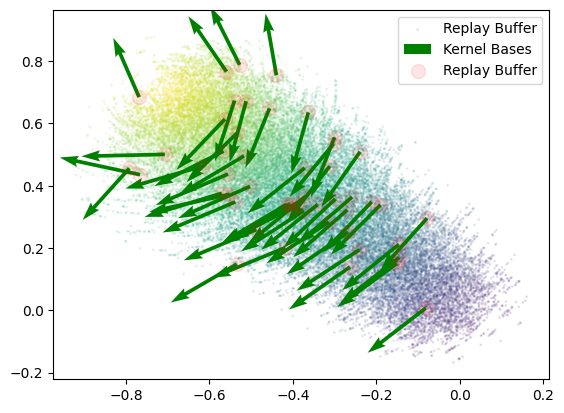

In [2]:
import pickle
import os
import torch
import numpy as np

run_dir="data/local/experiment/2d_navigation/circle_task_geometry/task_0"
kernel_dir = os.path.join(run_dir, "kernel_bases.pkl")
ps_dir = os.path.join(run_dir, "all_ps.pt")
ns_dir = os.path.join(run_dir, "all_ns.pt")

with open(kernel_dir, 'rb') as f:
    _kernel_bases = pickle.load(f)
with open(ps_dir, 'rb') as f:
    _ps = torch.load(f)
    _ns = torch.load(ns_dir)

kernel_bases = torch.stack(list(_kernel_bases.values()), dim=0)
ps = _ps[list(_kernel_bases.keys())]
ns = _ns[list(_kernel_bases.keys())]
del _kernel_bases, _ps, _ns

import matplotlib.pyplot as plt
N_plot = np.random.randint(low=0, high=25_000, size=50)
ps_plot = ps[N_plot]
kernel_bases_plot = kernel_bases[N_plot]
plt.scatter(ps[:, 0], ps[:, 1], c=ns, alpha=0.1, label="Replay Buffer", s=1)
plt.quiver(ps_plot[:, 0], ps_plot[:, 1], kernel_bases_plot[:, 0].detach().numpy(), 
           kernel_bases_plot[:, 1].detach().numpy(), angles='xy', scale_units='xy', scale=5, color='green', label="Kernel Bases")
plt.scatter(ps_plot[:, 0], ps_plot[:, 1], c='red', alpha=0.1, label="Replay Buffer", s=100)
plt.legend()

In [3]:
%load_ext autoreload
%autoreload 2

In [56]:
from src.learning.bb_symmetry.utils import train_neural_kernel

default_args = {
    'ps': ps,
    'kernel_bases': kernel_bases,
    'hidden_layer_dims': [16, 8],
    'epochs': 5000,
    'batch_size': 126,
    'sample_data_how': "uniform_replay",
    'temperature': None,
}
losses={}
networks={}

temperatures=[1, 10, 25, 50, 100]

networks["uniform_replay", None], losses["uniform_replay", None] = train_neural_kernel(**default_args)
for temperature in temperatures:
    sample_data_how="uniform_manifold"
    args = default_args.copy()
    args['temperature'] = temperature
    args['sample_data_how'] = sample_data_how
    networks[sample_data_how, temperature], losses[sample_data_how, temperature] = train_neural_kernel(**args)

Training Neural Kernel:   0%|          | 0/5000 [00:00<?, ?epoch/s]INFO:root:Initializing uniform manifold sampling
INFO:root:Initialized uniform manifold sampling
Training Neural Kernel:   0%|          | 0/5000 [00:00<?, ?epoch/s]INFO:root:Initializing uniform manifold sampling
INFO:root:Initialized uniform manifold sampling
Training Neural Kernel:   0%|          | 0/5000 [00:00<?, ?epoch/s]INFO:root:Initializing uniform manifold sampling
INFO:root:Initialized uniform manifold sampling
Training Neural Kernel:   0%|          | 0/5000 [00:00<?, ?epoch/s]INFO:root:Initializing uniform manifold sampling
INFO:root:Initialized uniform manifold sampling
Training Neural Kernel:   0%|          | 0/5000 [00:00<?, ?epoch/s]INFO:root:Initializing uniform manifold sampling
INFO:root:Initialized uniform manifold sampling
Training Neural Kernel: 100%|██████████| 5000/5000 [00:21<00:00, 230.69epoch/s, loss=0.123] 


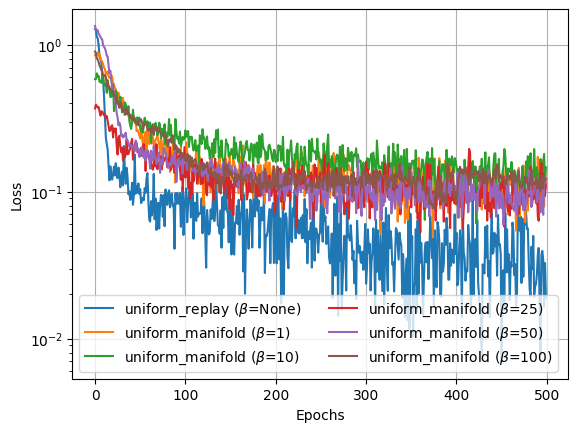

In [59]:
plot_every=10
import matplotlib.pyplot as plt
for key, loss in losses.items():
    plt.plot(loss[::plot_every], label=fr"{key[0]} ($\beta$={key[1]})")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.yscale("log")
plt.legend(ncols=2)

In [60]:
def create_linear_mesh(num_points):
    x = torch.linspace(-1, 0, num_points)
    y = torch.linspace(0, 1, num_points)
    grid_x, grid_y = torch.meshgrid(x, y)
    mesh_points = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
    return mesh_points

/var/folders/cm/rfx_nb1x16zcxk4frrwkp_1r0000gn/T/ipykernel_24707/492567372.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


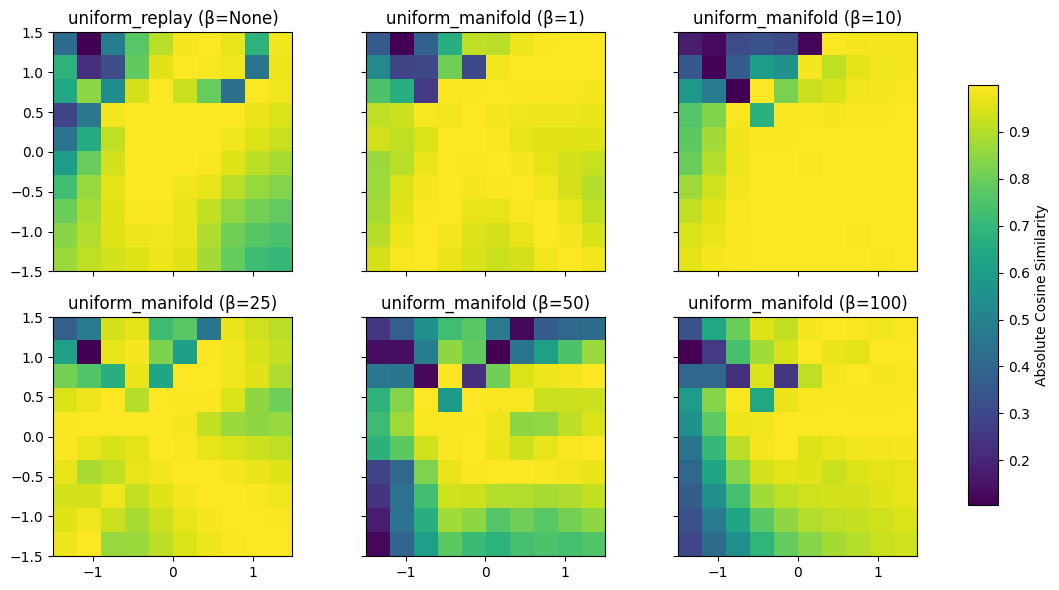

In [69]:
def oracle_frame_estimator(ps):
    """
    Oracle frame estimator for the circle task.
    """
    oracle_kernel=torch.tensor([[0, -1], [1,0]], dtype=torch.float32)
    ps = ps.clone().detach()
    ps = ps - torch.tensor([-0.7, 0.7], dtype=torch.float32)
    return ps @ oracle_kernel.T


num_points = 10
ps_eval = create_linear_mesh(num_points)
cosine_sims={}

oracle_frame = oracle_frame_estimator(ps_eval)
fig, axs = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
idx=0
cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
for name_network, network in networks.items():
    frame_hat = network(ps_eval).squeeze(-1)
    cosine_sim = torch.abs(torch.nn.functional.cosine_similarity(frame_hat, oracle_frame, dim=1))
    cosine_sims[name_network]=cosine_sim
    im = axs[idx // 3, idx % 3].imshow(cosine_sim.view(num_points, num_points).detach().numpy().T, extent=[-1.5, 1.5, -1.5, 1.5], origin='lower', cmap='viridis')
    axs[idx // 3, idx % 3].set_title(f"{name_network[0]} (β={name_network[1]})")
    axs[idx // 3, idx % 3].set_aspect('equal')
    idx += 1
fig.colorbar(im, cax=cbar_ax, label='Absolute Cosine Similarity')
fig.tight_layout()

(-1.0, 1.5)

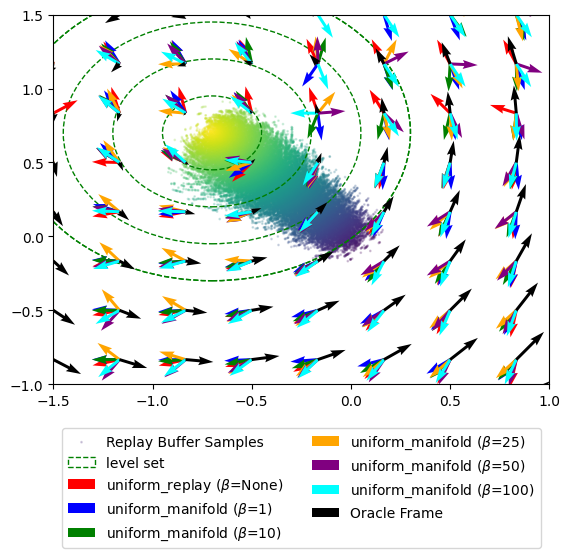

In [70]:
import matplotlib.pyplot as plt
colors=['red', 'blue', 'green', 'orange', 'purple', 'cyan']

goal = np.array([-0.7, 0.7])
plt.scatter(ps[:,0], ps[:,1], c=ns, s=1, label='Replay Buffer Samples', alpha=0.2)
circle_radii = [0.25, 0.5, 0.75, 1]
for radius in circle_radii:
    circle = plt.Circle(goal, radius, color='green', fill=False, linestyle='--')
    plt.gca().add_artist(circle)
circle = plt.Circle(goal, radius, color='green', fill=False, linestyle='--', label="level set")
plt.gca().add_artist(circle)

idx=0
for name_network, network in networks.items():
    frame_hat = network(ps_eval).squeeze(-1)
    plt.quiver(ps_eval[:,0], ps_eval[:,1], frame_hat.detach().numpy()[:,0], frame_hat.detach().numpy()[:,1], color=colors[idx],label=fr"{name_network[0]} ($\beta$={name_network[1]})", alpha=1)
    idx += 1
plt.quiver(ps_eval[:,0], ps_eval[:,1], oracle_frame.detach().numpy()[:,0], oracle_frame.detach().numpy()[:,1], color='black', label="Oracle Frame", alpha=1)
plt.legend(ncols=2, loc='upper center', bbox_to_anchor=(0.5, -0.1))
plt.xlim(-1.5, 1)
plt.ylim(-1, 1.5)